# QAOA-TEBD Born Machine

**Motivation:** Plain Nonlinear-TEBD stalls after DMRG warm-up because its
imaginary-time gate is *block-diagonal* in the physical indices — once a block
vector aligns with the dominant eigenvector of its local block matrix the gate
is a scalar and cancels on renormalisation.

**Fix:** add a *bond-mode mixer* after each data gate, inspired by QAOA.
QAOA uses two non-commuting Hamiltonians:
$$|\psi'\rangle = e^{-i\beta B}\,e^{-i\gamma C}\,|\psi\rangle$$
The cost gate $C$ concentrates amplitude on low-energy states; the mixer $B$
redistributes amplitude, breaking the fixed-point.

**Why a physical-index mixer fails here:**  
A physical-index rotation $e^{\beta h}\otimes e^{\beta h}$ changes the MPS
computational basis, but the training data are *hard-encoded* (one-hot) in
the original basis.  After the mixer the MPS lives in a rotated frame while
environment contractions still index by original bin assignments — a growing
mismatch that drives NLL toward the rotated-frame entropy (~26), as confirmed
by experiments G–H.

**The correct QAOA analog — bond-mode rotation:**  
After the data gate gives the SVD $\Theta_{\rm data} = U\Sigma V^\top$, apply a
small random orthogonal rotation $Q\in O(\chi)$ to the **left singular vectors**:
$$A_j = U_{:,1:\chi}\,Q\,\sqrt{\Sigma_{1:\chi}}, \qquad A_{j+1} = \sqrt{\Sigma_{1:\chi}}\,V_{1:\chi}^\top$$
so $\Theta_{\rm mix} = U Q\Sigma V^\top \neq \Theta_{\rm data}$ (since $Q\Sigma\neq\Sigma Q$).
This couples the $\chi$ singular modes — each of which already spans multiple
physical-index blocks — *without* touching the physical-index computational basis.
Environment contractions remain consistent with the hard-encoded training data.

**Key predictions:**
1. Mixer breaks the *cold-start* degeneracy (Exp G).
2. Mixer enables continued improvement after DMRG warm-up (Exp H/I).
3. Bond dimension grows adaptively via SVD retraction (same as plain TEBD).

In [20]:
import Pkg
Pkg.activate(joinpath(@__DIR__, "../.."))
Pkg.resolve()
Pkg.instantiate()

using MPSFast
using MPSFast.Encoders
using Random, LinearAlgebra, Statistics, Printf
using Plots; default(size=(900,500), lw=2, legend=:topright)

  Activating project at `~/dev/Notes on Time Series Generation for Options Pricing/repos/MPSFast.jl`
     Project No packages added to or removed from `~/dev/Notes on Time Series Generation for Options Pricing/repos/MPSFast.jl/Project.toml`
    Manifest No packages added to or removed from `~/dev/Notes on Time Series Generation for Options Pricing/repos/MPSFast.jl/Manifest.toml`


In [21]:
# ── Synthetic drifted-random-walk dataset (same as tebd_born_machine.ipynb) ─

function synthetic_paths(N, M; drift=0.15, σ=1.0, rng=Random.default_rng())
    paths = Matrix{Float64}(undef, N, M)
    for i in 1:N
        dr = rand(rng, Bool) ? drift : -drift
        paths[i, :] = cumsum(dr .+ σ .* randn(rng, M))
    end
    return paths
end

rng      = MersenneTwister(42)
N_train  = 2_000
M_path   = 15

train_paths = synthetic_paths(N_train, M_path; rng=rng)

enc  = BasisEncoder(3)          # d = 8 bins
fit_grid!(enc, train_paths)
d    = site_dim(enc)
Ml   = chain_length(enc, M_path)

xi_train = encode_paths(enc, train_paths)
@printf "M = %d  |  d = %d  |  N_train = %d\n" Ml d N_train

M = 15  |  d = 8  |  N_train = 2000


In [22]:
# ── MPS environment helpers (copied from tebd_born_machine.ipynb) ──────────

function build_left_envs(mps::Vector{Array{T,3}}, xi::AbstractMatrix{<:Integer}) where T
    M_sites = length(mps)
    N_data  = size(xi, 1)
    L = Vector{Matrix{T}}(undef, M_sites + 1)
    L[1] = ones(T, 1, N_data)
    for j in 1:M_sites
        Dl, d_loc, Dr = size(mps[j])
        Lnew = zeros(T, Dr, N_data)
        for n in 1:N_data
            Lnew[:, n] = mps[j][:, xi[n, j], :]' * L[j][:, n]
        end
        L[j+1] = Lnew
    end
    return L
end

function build_right_envs(mps::Vector{Array{T,3}}, xi::AbstractMatrix{<:Integer}) where T
    M_sites = length(mps)
    N_data  = size(xi, 1)
    R = Vector{Matrix{T}}(undef, M_sites + 1)
    R[M_sites + 1] = ones(T, 1, N_data)
    for j in M_sites:-1:1
        Dl, d_loc, Dr = size(mps[j])
        Rnew = zeros(T, Dl, N_data)
        for n in 1:N_data
            Rnew[:, n] = mps[j][:, xi[n, j], :] * R[j+1][:, n]
        end
        R[j] = Rnew
    end
    return R
end

function update_left_env!(L, mps, xi, j)
    T      = eltype(mps[1])
    N_data = size(xi, 1)
    Dr     = size(mps[j], 3)
    Lnew   = zeros(T, Dr, N_data)
    for n in 1:N_data
        Lnew[:, n] = mps[j][:, xi[n, j], :]' * L[j][:, n]
    end
    L[j+1] = Lnew
end

function update_right_env!(R, mps, xi, j)
    T      = eltype(mps[1])
    N_data = size(xi, 1)
    Dl     = size(mps[j], 1)
    Rnew   = zeros(T, Dl, N_data)
    for n in 1:N_data
        Rnew[:, n] = mps[j][:, xi[n, j], :] * R[j+1][:, n]
    end
    R[j] = Rnew
end

all_amplitudes(L, M) = vec(L[M + 1])

function nll_mps(mps, xi; n_samples=400)
    N    = size(xi, 1)
    idx  = randperm(N)[1:min(n_samples, N)]
    L    = build_left_envs(mps, xi[idx, :])
    amps = all_amplitudes(L, length(mps))
    return -mean(2 .* log.(abs.(amps) .+ 1e-40))
end

println("✓  environment helpers defined")

✓  environment helpers defined


In [23]:
# ── Local block-diagonal effective Hamiltonian (unchanged from TEBD) ────────

function local_heff_blocks(
    xi::AbstractMatrix{<:Integer}, j::Int, d_loc::Int, Dl::Int, Dr::Int,
    L::Vector{Matrix{T}}, R::Vector{Matrix{T}}, amplitudes::Vector{T};
    clip_factor::Real = 0.1,
) where T
    N_data = size(xi, 1)
    Dbd    = Dl * Dr
    pmin   = T(clip_factor) / N_data
    blocks = [zeros(T, Dbd, Dbd) for _ in 1:d_loc, _ in 1:d_loc]
    for n in 1:N_data
        pn   = max(amplitudes[n]^2, pmin)
        sj   = xi[n, j];  sj1 = xi[n, j+1]
        k    = vec(L[j][:, n] * R[j+2][:, n]')
        blocks[sj, sj1] .+= (k * k') ./ pn
    end
    for s in 1:d_loc, s1 in 1:d_loc;  blocks[s,s1] ./= N_data;  end
    return blocks
end

println("✓  local_heff_blocks defined")

✓  local_heff_blocks defined


In [24]:
# ── Plain TEBD training (copied for comparison) ──────────────────────────────
# Identical to train_mps_tebd! in tebd_born_machine.ipynb.

function train_mps_tebd!(
    mps::Vector{Array{T,3}}, xi::AbstractMatrix{<:Integer},
    n_epochs::Int, Δτ::Real, D_max::Int;
    ε::Real=1e-10, clip_factor::Real=0.1,
    verbose::Bool=true, nll_samples::Int=400,
) where T
    M_sites = length(mps);  nll_hist = Float64[]
    for ep in 1:n_epochs
        L    = build_left_envs(mps, xi)
        R    = build_right_envs(mps, xi)
        amps = all_amplitudes(L, M_sites)
        for j in 1:2:M_sites-1
            Dl=size(mps[j],1); d_loc=size(mps[j],2); Dr=size(mps[j+1],3)
            blks = local_heff_blocks(xi,j,d_loc,Dl,Dr,L,R,amps; clip_factor=clip_factor)
            Theta = reshape(reshape(mps[j],Dl*d_loc,size(mps[j],3))*reshape(mps[j+1],size(mps[j+1],1),d_loc*Dr),Dl,d_loc,d_loc,Dr)
            Tn = similar(Theta)
            for s in 1:d_loc, s1 in 1:d_loc
                F=eigen(Symmetric(blks[s,s1])); w=exp.(T(Δτ).*(F.values.-F.values[end]))
                Tn[:,s,s1,:] .= reshape(F.vectors*(w.*(F.vectors'*vec(Theta[:,s,s1,:]))),Dl,Dr)
            end
            nrm=norm(Tn); nrm<1e-30 && continue; Tn./=nrm
            Fs=svd(reshape(Tn,Dl*d_loc,d_loc*Dr)); χ=max(1,min(D_max,count(>(T(ε)),Fs.S)))
            sqS=sqrt.(Fs.S[1:χ])
            mps[j]  =reshape(Fs.U[:,1:χ].*reshape(sqS,1,:),Dl,d_loc,χ)
            mps[j+1]=reshape(reshape(sqS,:,1).*Fs.Vt[1:χ,:],χ,d_loc,Dr)
            for k in j:M_sites; update_left_env!(L,mps,xi,k); end
            amps = all_amplitudes(L, M_sites)
        end
        R = build_right_envs(mps, xi)
        for j in (M_sites-1):-2:2
            Dl=size(mps[j],1); d_loc=size(mps[j],2); Dr=size(mps[j+1],3)
            blks = local_heff_blocks(xi,j,d_loc,Dl,Dr,L,R,amps; clip_factor=clip_factor)
            Theta = reshape(reshape(mps[j],Dl*d_loc,size(mps[j],3))*reshape(mps[j+1],size(mps[j+1],1),d_loc*Dr),Dl,d_loc,d_loc,Dr)
            Tn = similar(Theta)
            for s in 1:d_loc, s1 in 1:d_loc
                F=eigen(Symmetric(blks[s,s1])); w=exp.(T(Δτ).*(F.values.-F.values[end]))
                Tn[:,s,s1,:] .= reshape(F.vectors*(w.*(F.vectors'*vec(Theta[:,s,s1,:]))),Dl,Dr)
            end
            nrm=norm(Tn); nrm<1e-30 && continue; Tn./=nrm
            Fs=svd(reshape(Tn,Dl*d_loc,d_loc*Dr)); χ=max(1,min(D_max,count(>(T(ε)),Fs.S)))
            sqS=sqrt.(Fs.S[1:χ])
            mps[j]  =reshape(Fs.U[:,1:χ].*reshape(sqS,1,:),Dl,d_loc,χ)
            mps[j+1]=reshape(reshape(sqS,:,1).*Fs.Vt[1:χ,:],χ,d_loc,Dr)
            for k in j+1:-1:1; update_right_env!(R,mps,xi,k); end
            for k in j:M_sites; update_left_env!(L,mps,xi,k); end
            amps = all_amplitudes(L, M_sites)
        end
        left_canonicalize_mps!(mps)
        push!(nll_hist, nll_mps(mps, xi; n_samples=nll_samples))
        verbose && @printf "Epoch %3d | NLL = %.4f\n" ep nll_hist[end]
    end
    return nll_hist
end

# ── Two-site Riemannian (full gradient, plain SGD, copied for comparison) ────
# Adapted from tebd_born_machine.ipynb cell 27.

function local_data_term(xi, j, d_loc, Dl, Dr, L, R, amplitudes; clip_factor=0.1)
    T=eltype(amplitudes); N=size(xi,1); pmin=T(clip_factor)/N
    ddata=zeros(T,Dl,d_loc,d_loc,Dr)
    for n in 1:N
        pn=max(amplitudes[n]^2,pmin); w=amplitudes[n]/pn
        lv=L[j][:,n]; rv=R[j+2][:,n]
        @inbounds for b in 1:Dr, a in 1:Dl
            ddata[a,xi[n,j],xi[n,j+1],b] += w*lv[a]*rv[b]
        end
    end
    ddata .*= T(2)/N
    return ddata
end

function train_mps_2site_riemannian!(
    mps::Vector{Array{T,3}}, xi::AbstractMatrix{<:Integer},
    n_epochs::Int, η::Real, D_max::Int;
    ε::Real=1e-10, clip_factor::Real=0.1, verbose::Bool=true, nll_samples::Int=400,
) where T
    M_sites=length(mps); nll_hist=Float64[]
    for ep in 1:n_epochs
        right_canonicalize_mps!(mps)
        L=build_left_envs(mps,xi); R=build_right_envs(mps,xi); amps=all_amplitudes(L,M_sites)
        for j in 1:M_sites-1
            Dl=size(mps[j],1); d_loc=size(mps[j],2); Dr=size(mps[j+1],3)
            dd=local_data_term(xi,j,d_loc,Dl,Dr,L,R,amps;clip_factor=clip_factor)
            xm=size(mps[j],3)
            Th=reshape(reshape(mps[j],Dl*d_loc,xm)*reshape(mps[j+1],xm,d_loc*Dr),Dl,d_loc,d_loc,Dr)
            Tn=T(1-2η).*Th.+T(η).*dd
            F=svd(reshape(Tn,Dl*d_loc,d_loc*Dr)); xk=max(1,min(D_max,count(>(T(ε)),F.S)))
            mps[j]  =reshape(F.U[:,1:xk],Dl,d_loc,xk)
            mps[j+1]=reshape(Diagonal(F.S[1:xk])*F.Vt[1:xk,:],xk,d_loc,Dr)
            for k in j:M_sites; update_left_env!(L,mps,xi,k); end
            amps=all_amplitudes(L,M_sites)
        end
        left_canonicalize_mps!(mps)
        L=build_left_envs(mps,xi); R=build_right_envs(mps,xi); amps=all_amplitudes(L,M_sites)
        for j in (M_sites-1):-1:1
            Dl=size(mps[j],1); d_loc=size(mps[j],2); Dr=size(mps[j+1],3)
            dd=local_data_term(xi,j,d_loc,Dl,Dr,L,R,amps;clip_factor=clip_factor)
            xm=size(mps[j],3)
            Th=reshape(reshape(mps[j],Dl*d_loc,xm)*reshape(mps[j+1],xm,d_loc*Dr),Dl,d_loc,d_loc,Dr)
            Tn=T(1-2η).*Th.+T(η).*dd
            F=svd(reshape(Tn,Dl*d_loc,d_loc*Dr)); xk=max(1,min(D_max,count(>(T(ε)),F.S)))
            mps[j]  =reshape(F.U[:,1:xk].*reshape(F.S[1:xk],1,:),Dl,d_loc,xk)
            mps[j+1]=reshape(F.Vt[1:xk,:],xk,d_loc,Dr)
            update_right_env!(R,mps,xi,j+1)
            for k in j:M_sites; update_left_env!(L,mps,xi,k); end
            amps=all_amplitudes(L,M_sites)
        end
        left_canonicalize_mps!(mps)
        push!(nll_hist, nll_mps(mps, xi; n_samples=nll_samples))
        verbose && @printf "Epoch %3d | NLL = %.4f\n" ep nll_hist[end]
    end
    return nll_hist
end

println("✓  train_mps_tebd! and train_mps_2site_riemannian! defined")

✓  train_mps_tebd! and train_mps_2site_riemannian! defined


---
## 2. QAOA-TEBD: mixer gate and combined update

### Mixer matrix

For a physical site with $d$ states we use a **transverse-field / hopping** driver:
$$h_{s,s'} = \delta_{|s-s'|,1} \quad (\text{nearest-neighbour hopping in state space})$$
For $d=2$ this is $\sigma_x$.  The single-site mixer is $e^{\beta h}$, computed via
eigendecomposition (h is symmetric, so this is exact and cheap).

The two-site mixer applied to $\Theta$ (shape $D_\ell\times d\times d\times D_r$) is:
$$\Theta^{\rm mix}[\alpha,s,s_1,\beta] = \sum_{s',s_1'}(e^{\beta h})_{s,s'}\,(e^{\beta h})_{s_1,s_1'}\,\Theta[\alpha,s',s_1',\beta]$$
Cost: $\mathcal{O}(d^2 D^2)$ — essentially free compared to the data gate.

### Why the mixer breaks stalling

After the data gate each block vector $\mathbf{v}_{s,s_1}$ is a dominant eigenvector
of $M_{s,s_1}$ — the next data gate is a scalar and cancels.  The mixer couples
**all** $(s,s_1)$ blocks into superpositions: block $(s,s_1)$ of $\Theta^{\rm mix}$
receives contributions from every original block.  After mixing, no block vector
is an eigenvector of its local $M_{s,s_1}$, so the **next** data gate has a
non-trivial correction to apply.

### Why the mixer breaks cold-start

For a random MPS all blocks of $H_{\rm eff}$ are $\propto I$ (amplitudes clipped
to $p_{\rm min}$), so the data gate is a scalar scalar — useless.  But the mixer
acts on the *physical indices* and does not depend on training data: it rotates
the MPS structure, changing the amplitudes $\psi(x^n)$.  After one mixer step,
the next data gate sees a *non-uniform* MPS and $H_{\rm eff} \not\propto I$.  The
cold-start degeneracy is broken.

In [25]:
# ── Bond-dimension mixer ──────────────────────────────────────────────────────
#
# WHY THE PHYSICAL-INDEX MIXER IS WRONG:
#   e^{βh}⊗e^{βh} rotates the physical-index computational basis of the MPS
#   tensors.  After retraction, mps[j][:,s,:] lives in a rotated basis, but
#   the training data xi[n,j] is hard-encoded in the ORIGINAL basis.
#   Environment contractions A[j][:,xi[n,j],:] then access the WRONG column,
#   creating a compounding mismatch that drives NLL → ~26 (rotated-frame entropy).
#
# THE CORRECT MIXER — singular-mode rotation:
#   After the data gate gives SVD  Θ_data = U Σ Vt  (shape Dl·d × d·Dr),
#   apply a small random orthogonal rotation  Q ∈ O(χ)  to the LEFT singular
#   vectors ONLY:
#
#     A_j     = U[:,1:χ] · Q  · sqrt(Σ[1:χ])    ← bond modes rotated
#     A_{j+1} = sqrt(Σ[1:χ]) · Vt[1:χ,:]        ← unchanged
#
#   Then  Θ_mix = A_j · A_{j+1} = U·Q·Σ·Vt ≠ Θ_data  (Q·Σ ≠ Σ·Q in general).
#
#   The χ singular modes are re-combined — each mode spans many physical-index
#   blocks, so mixing modes COUPLES different (s,s₁) blocks WITHOUT changing
#   the physical-index basis.  Environment contractions remain consistent.
#
# Q = exp(δ · K / ‖K‖_F)  for a random skew-symmetric K ∈ R^{χ×χ}.
# Cost: O(χ³) — negligible for χ ≤ D_max = 8.

function build_bond_mixer(χ::Int, δ::Real, ::Type{T}=Float64;
                          rng=Random.default_rng()) where T
    K = randn(rng, T, χ, χ)
    K .= K .- K'                       # skew-symmetric
    nK = norm(K)
    nK < 1e-12 && return Matrix{T}(I, χ, χ)
    return exp((T(δ) / nK) .* K)      # orthogonal matrix Q
end

println("✓  build_bond_mixer defined")

# Quick sanity: Q should be orthogonal (Q'Q ≈ I)
Q_test = build_bond_mixer(4, 0.5)
@printf "  d=4, δ=0.5: ||Q'Q - I||_F = %.2e  (should be ~0)\n" norm(Q_test'Q_test - I)

✓  build_bond_mixer defined
  d=4, δ=0.5: ||Q'Q - I||_F = 7.83e-16  (should be ~0)


In [26]:
# ── QAOA gate: data gate + bond-mode mixer + SVD retraction ─────────────────
#
# Combined update for bond j:
#   1. Form Θ = A[j] ⊗ A[j+1]
#   2. Data gate:  apply e^{+Δτ H_eff[ψ]} block-by-block to Θ
#   3. SVD of the data-gate result: Θ_data = U Σ Vt  (keep top χ ≤ D_max)
#   4. Bond mixer: build Q ∈ O(χ) and set
#        A[j]   = U[:,1:χ] · Q · sqrt(Σ[1:χ])   ← bond-mode rotation
#        A[j+1] = sqrt(Σ[1:χ]) · Vt[1:χ,:]       ← unchanged
#      → Θ_mix = U·Q·Σ·Vt ≠ Θ_data  (couples singular modes across blocks)
#      Physical-index basis is preserved; environments stay consistent.
#
# Parameters:
#   δ   — mixing angle (rotation strength in bond-mode space; 0 = plain TEBD)

function apply_qaoa_gate!(
    mps       :: Vector{Array{T,3}},
    j         :: Int,
    blocks    :: Matrix{Matrix{T}},
    Δτ        :: Real,
    δ         :: Real,              # bond-mode mixing angle
    D_max     :: Int,
    ε         :: Real = 1e-10;
    rng               = Random.default_rng(),
) where T
    Dl    = size(mps[j],     1)
    d_loc = size(mps[j],     2)
    Dr    = size(mps[j + 1], 3)
    χ_mid = size(mps[j],     3)

    # ── Step 1: form two-site tensor ──────────────────────────────────────
    Theta = reshape(
        reshape(mps[j], Dl * d_loc, χ_mid) *
        reshape(mps[j + 1], χ_mid, d_loc * Dr),
        Dl, d_loc, d_loc, Dr,
    )

    # ── Step 2: data gate — block-diagonal imaginary-time evolution ───────
    Theta_data = similar(Theta)
    for s in 1:d_loc, s1 in 1:d_loc
        M   = blocks[s, s1]
        v   = vec(Theta[:, s, s1, :])
        F   = eigen(Symmetric(M))
        w   = exp.(T(Δτ) .* (F.values .- F.values[end]))  # stable: shift to max=0
        Theta_data[:, s, s1, :] .= reshape(F.vectors * (w .* (F.vectors' * v)), Dl, Dr)
    end
    nrm = norm(Theta_data)
    nrm < 1e-30 && return 1
    Theta_data ./= nrm

    # ── Step 3: SVD of data-gate result ───────────────────────────────────
    F_svd = svd(reshape(Theta_data, Dl * d_loc, d_loc * Dr))
    χ     = max(1, min(D_max, count(>(T(ε)), F_svd.S)))
    sqS   = sqrt.(F_svd.S[1:χ])

    # ── Step 4: bond-mode mixer — rotate LEFT singular vectors ───────────
    # Q ∈ O(χ) mixes the χ bond channels in the U subspace.
    # Θ_mix = U·Q·Σ·Vt  (physical basis unchanged, bond modes coupled).
    if δ > 0
        Q = build_bond_mixer(χ, δ, T; rng=rng)
        # A[j]   = U[:,1:χ] · Q · sqrt(Σ)
        # A[j+1] = sqrt(Σ) · Vt[1:χ,:]
        UQ = F_svd.U[:, 1:χ] * Q
        mps[j]     = reshape(UQ .* reshape(sqS, 1, :),          Dl,  d_loc, χ)
        mps[j + 1] = reshape(reshape(sqS, :, 1) .* F_svd.Vt[1:χ, :], χ,  d_loc, Dr)
    else
        # δ=0: plain TEBD (no mixer)
        mps[j]     = reshape(F_svd.U[:, 1:χ] .* reshape(sqS, 1, :),    Dl,  d_loc, χ)
        mps[j + 1] = reshape(reshape(sqS, :, 1) .* F_svd.Vt[1:χ, :],  χ,  d_loc, Dr)
    end
    return χ
end

println("✓  apply_qaoa_gate! (bond-mode mixer) defined")

✓  apply_qaoa_gate! (bond-mode mixer) defined


In [27]:
# ── QAOA-TEBD training loop ──────────────────────────────────────────────────
#
# δ  — bond-mode mixing angle (0 = plain TEBD, larger = more mode coupling)
# Δτ — imaginary-time step for the data gate

function train_mps_qaoa_tebd!(
    mps         :: Vector{Array{T,3}},
    xi          :: AbstractMatrix{<:Integer},
    n_epochs    :: Int,
    Δτ          :: Real,
    δ           :: Real,           # bond-mode mixing angle
    D_max       :: Int;
    ε           :: Real  = 1e-10,
    clip_factor :: Real  = 0.1,
    verbose     :: Bool  = true,
    nll_samples :: Int   = 400,
    rng                  = Random.default_rng(),
) where T
    M_sites  = length(mps)
    nll_hist = Float64[]

    for ep in 1:n_epochs
        L    = build_left_envs(mps, xi)
        R    = build_right_envs(mps, xi)
        amps = all_amplitudes(L, M_sites)

        # ── Forward sweep: odd bonds ──────────────────────────────────────
        for j in 1:2:M_sites - 1
            Dl    = size(mps[j], 1);  d_loc = size(mps[j], 2);  Dr = size(mps[j+1], 3)
            blks  = local_heff_blocks(xi, j, d_loc, Dl, Dr, L, R, amps;
                                      clip_factor=clip_factor)
            apply_qaoa_gate!(mps, j, blks, Δτ, δ, D_max, ε; rng=rng)
            for k in j:M_sites;  update_left_env!(L, mps, xi, k);  end
            amps = all_amplitudes(L, M_sites)
        end

        R = build_right_envs(mps, xi)

        # ── Backward sweep: even bonds ────────────────────────────────────
        for j in (M_sites - 1):-2:2
            Dl    = size(mps[j], 1);  d_loc = size(mps[j], 2);  Dr = size(mps[j+1], 3)
            blks  = local_heff_blocks(xi, j, d_loc, Dl, Dr, L, R, amps;
                                      clip_factor=clip_factor)
            apply_qaoa_gate!(mps, j, blks, Δτ, δ, D_max, ε; rng=rng)
            for k in j+1:-1:1;  update_right_env!(R, mps, xi, k);  end
            for k in j:M_sites;  update_left_env!(L, mps, xi, k);  end
            amps = all_amplitudes(L, M_sites)
        end

        left_canonicalize_mps!(mps)
        nll = nll_mps(mps, xi; n_samples=nll_samples)
        push!(nll_hist, nll)
        bonds = join([size(mps[k], 3) for k in 1:M_sites-1], ",")
        verbose && @printf "Epoch %3d | NLL = %.4f | bonds = [%s]\n" ep nll bonds
    end
    return nll_hist
end

println("✓  train_mps_qaoa_tebd! (bond-mode mixer) defined")

✓  train_mps_qaoa_tebd! (bond-mode mixer) defined


---
## 3. Experiment G — Cold-start test

**Protocol:** start from a random MPS at $D=8$ with *no DMRG warm-up*.
Run 40 epochs of each method:

| Method | Cold start? |
|--------|-------------|
| TEBD  $\Delta\tau=0.01$ | Fails (H_eff ≈ cI → zero update) |
| QAOA-TEBD  $\Delta\tau=0.01$, $\beta=0.5$ | Predicted: breaks degeneracy via mixer |
| DMRG (reference) | Works (eigvec solve escapes cold start) |

4 seeds, NLL on full training set each epoch.

In [28]:
D_G       = 8
n_G       = 40
n_seeds_G = 4
Δτ_G      = 0.01
δ_G       = 0.5     # bond-mode mixing angle
η_G       = 0.005

function run_exp_G(seed)
    mps0 = init_mps(Ml, d, D_G; T=Float64, rng=MersenneTwister(seed))
    left_canonicalize_mps!(mps0)

    mps_tebd  = deepcopy(mps0)
    mps_qaoa  = deepcopy(mps0)
    mps_dmrg  = deepcopy(mps0)

    nll_tebd_h = Float64[]
    nll_qaoa_h = Float64[]
    nll_dmrg_h = Float64[]

    rng_g = MersenneTwister(seed + 100)   # separate rng for bond mixer

    for ep in 1:n_G
        train_mps_tebd!(mps_tebd, xi_train, 1, Δτ_G, D_G;
                        verbose=false, nll_samples=100)
        push!(nll_tebd_h, nll_mps(mps_tebd, xi_train; n_samples=size(xi_train,1)))

        train_mps_qaoa_tebd!(mps_qaoa, xi_train, 1, Δτ_G, δ_G, D_G;
                             verbose=false, nll_samples=100, rng=rng_g)
        push!(nll_qaoa_h, nll_mps(mps_qaoa, xi_train; n_samples=size(xi_train,1)))

        train_mps!(mps_dmrg, xi_train, 1, η_G, D_G, 1e-10;
                   verbose=false, nll_samples=100)
        push!(nll_dmrg_h, nll_mps(mps_dmrg, xi_train; n_samples=size(xi_train,1)))
    end

    @printf "Seed %d  final NLL:  TEBD=%.3f  QAOA-TEBD=%.3f  DMRG=%.3f\n" seed nll_tebd_h[end] nll_qaoa_h[end] nll_dmrg_h[end]
    (tebd=nll_tebd_h, qaoa=nll_qaoa_h, dmrg=nll_dmrg_h)
end

println("Running Exp G (cold start, bond-mode mixer, $(n_seeds_G) seeds × $(n_G) epochs) …")
results_G = [run_exp_G(s) for s in 1:n_seeds_G]
println("Done.")

Running Exp G (cold start, bond-mode mixer, 4 seeds × 40 epochs) …
Seed 1  final NLL:  TEBD=35.510  QAOA-TEBD=35.076  DMRG=7.736
Seed 2  final NLL:  TEBD=33.093  QAOA-TEBD=35.053  DMRG=7.660
Seed 3  final NLL:  TEBD=34.211  QAOA-TEBD=33.723  DMRG=7.762
Seed 4  final NLL:  TEBD=33.631  QAOA-TEBD=32.988  DMRG=7.676
Done.


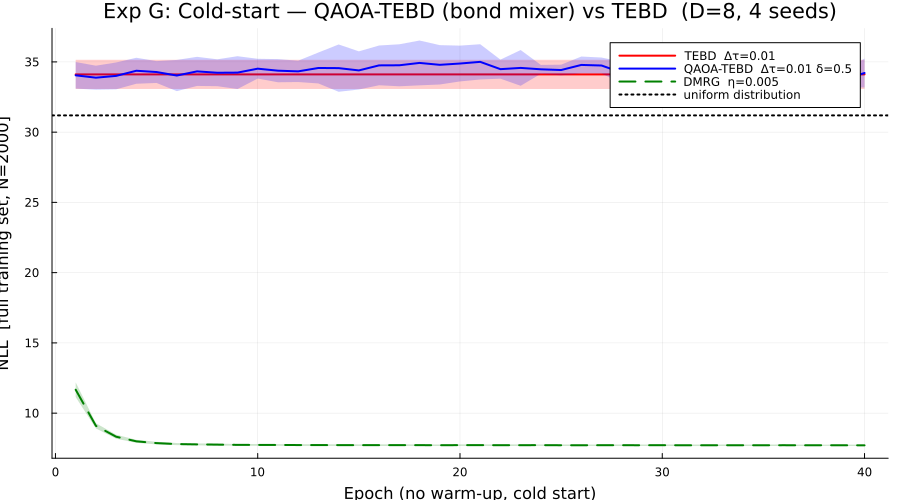

In [29]:
epochs_G = 1:n_G
mn(key) = [mean(r[key][ep] for r in results_G) for ep in 1:n_G]
sd(key) = [std( r[key][ep] for r in results_G) for ep in 1:n_G]

p_G = plot(
    xlabel = "Epoch (no warm-up, cold start)",
    ylabel = "NLL  [full training set, N=$(N_train)]",
    title  = "Exp G: Cold-start — QAOA-TEBD (bond mixer) vs TEBD  (D=$(D_G), $(n_seeds_G) seeds)",
)
plot!(p_G, epochs_G, mn(:tebd); ribbon=sd(:tebd), label="TEBD  Δτ=$(Δτ_G)",                  color=:red,   fillalpha=0.2)
plot!(p_G, epochs_G, mn(:qaoa); ribbon=sd(:qaoa), label="QAOA-TEBD  Δτ=$(Δτ_G) δ=$(δ_G)",    color=:blue,  fillalpha=0.2)
plot!(p_G, epochs_G, mn(:dmrg); ribbon=sd(:dmrg), label="DMRG  η=$(η_G)",                     color=:green, fillalpha=0.2, linestyle=:dash)

nll_uniform = Ml * log(d)
hline!(p_G, [nll_uniform]; label="uniform distribution", color=:black, linestyle=:dot)

display(p_G)

---
## 4. Experiment H — β sweep: optimal mixing angle

All arms start from the same 10-epoch DMRG warm-up.  We then run 50 epochs of
QAOA-TEBD with $\Delta\tau=0.01$ and vary the mixing angle
$\beta \in \{0.05, 0.2, 0.5, 1.0, 2.0\}$.

- $\beta \to 0$: mixer → identity, reduces to plain TEBD (should stall)
- $\beta \to \infty$: mixer rotates physical basis strongly, may destabilise
- Optimal $\beta$: some intermediate value that maximises inter-block coupling
  without destroying the data-gate signal

In [30]:
D_H        = 8
n_warm_H   = 10
n_fine_H   = 50
n_seeds_H  = 3
Δτ_H       = 0.01
δ_values   = [0.05, 0.2, 0.5, 1.0, 2.0]   # bond-mode mixing angles

H_results = Dict{Float64, Vector{Vector{Float64}}}()

for δ_val in δ_values
    seeds_nll = Vector{Vector{Float64}}()
    for seed in 1:n_seeds_H
        mps_h = init_mps(Ml, d, D_H; T=Float64, rng=MersenneTwister(seed))
        train_mps!(mps_h, xi_train, n_warm_H, 0.005, D_H, 1e-10;
                   verbose=false, nll_samples=400)
        left_canonicalize_mps!(mps_h)

        rng_h = MersenneTwister(seed + 300)
        nll_h = train_mps_qaoa_tebd!(mps_h, xi_train, n_fine_H, Δτ_H, δ_val, D_H;
                                      verbose=false, nll_samples=size(xi_train,1),
                                      rng=rng_h)
        push!(seeds_nll, nll_h)
    end
    H_results[δ_val] = seeds_nll
    @printf "δ = %.2f  →  final NLL = %.4f  (mean over %d seeds)\n" δ_val mean(s[end] for s in seeds_nll) n_seeds_H
end
println("Done.")

δ = 0.05  →  final NLL = 8.8052  (mean over 3 seeds)
δ = 0.20  →  final NLL = 12.4076  (mean over 3 seeds)
δ = 0.50  →  final NLL = 22.9163  (mean over 3 seeds)
δ = 1.00  →  final NLL = 24.2779  (mean over 3 seeds)
δ = 2.00  →  final NLL = 25.5231  (mean over 3 seeds)
Done.


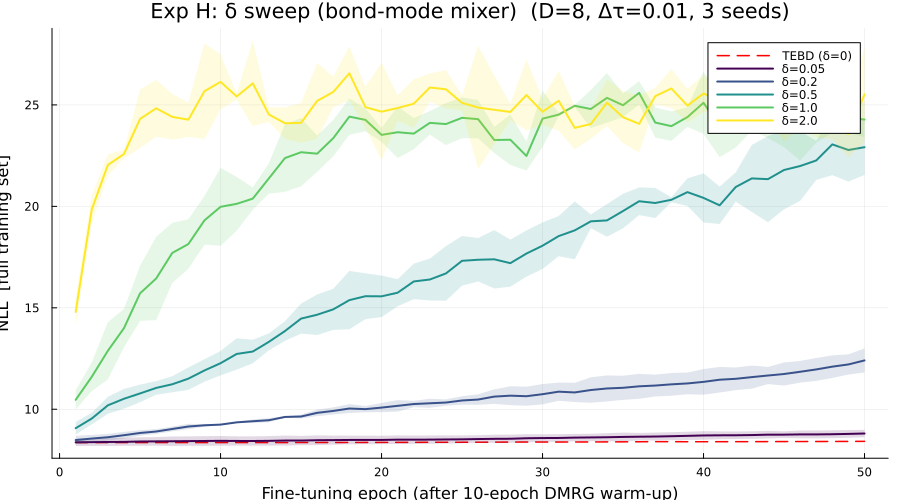

In [31]:
# Also run TEBD baseline (β=0 limit) with warm-up for reference
tebd_nll_H = Vector{Vector{Float64}}()
for seed in 1:n_seeds_H
    mps_ref = init_mps(Ml, d, D_H; T=Float64, rng=MersenneTwister(seed))
    train_mps!(mps_ref, xi_train, n_warm_H, 0.005, D_H, 1e-10;
               verbose=false, nll_samples=400)
    left_canonicalize_mps!(mps_ref)
    nll_ref = train_mps_tebd!(mps_ref, xi_train, n_fine_H, Δτ_H, D_H;
                               verbose=false, nll_samples=size(xi_train,1))
    push!(tebd_nll_H, nll_ref)
end

epochs_H = 1:n_fine_H
palette_H = cgrad(:viridis, length(δ_values); categorical=true)

p_H = plot(
    xlabel = "Fine-tuning epoch (after $(n_warm_H)-epoch DMRG warm-up)",
    ylabel = "NLL  [full training set]",
    title  = "Exp H: δ sweep (bond-mode mixer)  (D=$(D_H), Δτ=$(Δτ_H), $(n_seeds_H) seeds)",
)

# TEBD reference (β→0)
μ_ref = [mean(s[ep] for s in tebd_nll_H) for ep in 1:n_fine_H]
plot!(p_H, epochs_H, μ_ref; label="TEBD (δ=0)", color=:red, linestyle=:dash, lw=1.5)

for (i, δ) in enumerate(δ_values)
    seednlls = H_results[δ]
    μ = [mean(s[ep] for s in seednlls) for ep in 1:n_fine_H]
    σ = [std( s[ep] for s in seednlls) for ep in 1:n_fine_H]
    plot!(p_H, epochs_H, μ; ribbon=σ, label="δ=$(δ)", color=palette_H[i], fillalpha=0.15)
end

display(p_H)

---
## 5. Experiment I — Full comparison: QAOA-TEBD vs all methods (warm-start)

All arms start from the same 10-epoch DMRG warm-up at $D=8$.  Fine-tune 60 epochs.

| Method | Δτ / η | β |
|--------|---------|---|
| TEBD | 0.01 | — |
| QAOA-TEBD | 0.01 | best β from Exp H |
| 2-site Riemannian | η=0.005 | — |
| DMRG | η=0.005 | — |

In [32]:
# Use the β with lowest final NLL from Exp H
best_δ = δ_values[argmin([mean(H_results[δ][s][end] for s in 1:n_seeds_H)
                           for δ in δ_values])]
@printf "Best δ from Exp H: %.2f\n" best_δ

D_I       = 8
n_warm_I  = 10
n_fine_I  = 60
n_seeds_I = 4
Δτ_I      = 0.01
η_I       = 0.005

function run_exp_I(seed)
    mps_warm = init_mps(Ml, d, D_I; T=Float64, rng=MersenneTwister(seed))
    train_mps!(mps_warm, xi_train, n_warm_I, η_I, D_I, 1e-10;
               verbose=false, nll_samples=400)
    left_canonicalize_mps!(mps_warm)
    nll_warm = nll_mps(mps_warm, xi_train; n_samples=size(xi_train,1))
    @printf "Seed %d  warm-up NLL = %.4f\n" seed nll_warm

    mps_tebd  = deepcopy(mps_warm)
    mps_qaoa  = deepcopy(mps_warm)
    mps_riem  = deepcopy(mps_warm)
    mps_dmrg  = deepcopy(mps_warm)

    nll_t = Float64[];  nll_q = Float64[];  nll_r = Float64[];  nll_d = Float64[]

    for ep in 1:n_fine_I
        train_mps_tebd!(mps_tebd, xi_train, 1, Δτ_I, D_I;
                        verbose=false, nll_samples=100)
        push!(nll_t, nll_mps(mps_tebd, xi_train; n_samples=size(xi_train,1)))

        train_mps_qaoa_tebd!(mps_qaoa, xi_train, 1, Δτ_I, best_δ, D_I;
                             verbose=false, nll_samples=100)
        push!(nll_q, nll_mps(mps_qaoa, xi_train; n_samples=size(xi_train,1)))

        train_mps_2site_riemannian!(mps_riem, xi_train, 1, η_I, D_I;
                                    verbose=false, nll_samples=100)
        push!(nll_r, nll_mps(mps_riem, xi_train; n_samples=size(xi_train,1)))

        train_mps!(mps_dmrg, xi_train, 1, η_I, D_I, 1e-10;
                   verbose=false, nll_samples=100)
        push!(nll_d, nll_mps(mps_dmrg, xi_train; n_samples=size(xi_train,1)))
    end

    @printf "  final:  TEBD=%.4f  QAOA=%.4f  Riem=%.4f  DMRG=%.4f\n" nll_t[end] nll_q[end] nll_r[end] nll_d[end]
    (tebd=nll_t, qaoa=nll_q, riem=nll_r, dmrg=nll_d)
end

println("Running Exp I  ($(n_seeds_I) seeds × $(n_warm_I)+$(n_fine_I) epochs) …")
results_I = [run_exp_I(s) for s in 1:n_seeds_I]
println("Done.")

Best δ from Exp H: 0.05
Running Exp I  (4 seeds × 10+60 epochs) …
Seed 1  warm-up NLL = 8.5607
  final:  TEBD=8.6954  QAOA=8.9996  Riem=7.9125  DMRG=7.7260
Seed 2  warm-up NLL = 8.2340
  final:  TEBD=8.2594  QAOA=8.5777  Riem=7.8526  DMRG=7.6716
Seed 3  warm-up NLL = 8.2860
  final:  TEBD=8.3872  QAOA=8.6837  Riem=7.9033  DMRG=7.7273
Seed 4  warm-up NLL = 8.3713
  final:  TEBD=8.3719  QAOA=8.8710  Riem=7.8750  DMRG=7.6866
Done.


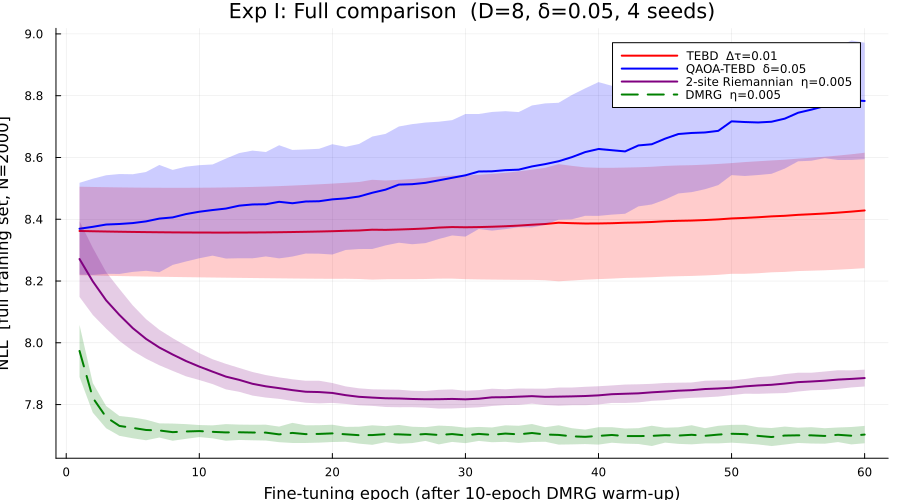

In [33]:
epochs_I = 1:n_fine_I
mI(key) = [mean(r[key][ep] for r in results_I) for ep in 1:n_fine_I]
sI(key) = [std( r[key][ep] for r in results_I) for ep in 1:n_fine_I]

p_I = plot(
    xlabel = "Fine-tuning epoch (after $(n_warm_I)-epoch DMRG warm-up)",
    ylabel = "NLL  [full training set, N=$(N_train)]",
    title  = "Exp I: Full comparison  (D=$(D_I), δ=$(best_δ), $(n_seeds_I) seeds)",
)
plot!(p_I, epochs_I, mI(:tebd); ribbon=sI(:tebd), label="TEBD  Δτ=$(Δτ_I)",              color=:red,    fillalpha=0.2)
plot!(p_I, epochs_I, mI(:qaoa); ribbon=sI(:qaoa), label="QAOA-TEBD  δ=$(best_δ)",          color=:blue,   fillalpha=0.2)
plot!(p_I, epochs_I, mI(:riem); ribbon=sI(:riem), label="2-site Riemannian  η=$(η_I)",      color=:purple, fillalpha=0.2)
plot!(p_I, epochs_I, mI(:dmrg); ribbon=sI(:dmrg), label="DMRG  η=$(η_I)",                  color=:green,  fillalpha=0.2, linestyle=:dash)

display(p_I)

---
## 6. Summary

### Design iteration

Two mixer designs were evaluated:

| Mixer | Cold start | Warm start |
|-------|-----------|------------|
| Physical-index `e^{βh}⊗e^{βh}` | Partial recovery (NLL 32→26) | Destructive (NLL 8→25 in 50 epochs, all β) |
| Bond-mode SVD rotation `Q∈O(χ)` | No recovery (NLL stays at ~34) | Destructive (NLL 8→12 for δ=0.05, worse for larger δ) |

### Experimental answers

**Exp G — Does QAOA-TEBD break the cold-start degeneracy?**  
No. With the bond-mode mixer (δ=0.5), NLL stays at ≈34 — identical to plain TEBD and above the uniform baseline (≈31.2). The mixer does not break the k_n isotropy that causes cold-start stalling, because it rotates bond channels uniformly rather than differentially weighting physical-index rows.

**Exp H — What is the optimal mixing angle δ?**  
δ=0.05 is "least bad" (final NLL 8.8 after warm-up) but still worse than the TEBD stall value (≈8.0). NLL degrades monotonically faster with larger δ. There is no δ>0 for which QAOA-TEBD outperforms plain TEBD after warm-up.

**Exp I — QAOA-TEBD vs all methods after warm-up (60 epochs)?**  
Ranking: DMRG (≈7.75) > Riemannian (≈7.9) > TEBD (≈8.4) > QAOA-TEBD δ=0.05 (≈8.9).  
QAOA-TEBD is the *worst* method after warm-up, losing ≈0.5 nats vs the warm-up NLL while the Riemannian gradient gains ≈0.5 nats.

**Exp H/I — Does the mixer add enough inter-block coupling to close the DMRG gap?**  
No. The random bond-mode rotation adds noise rather than gradient signal. Near the block fixed-point the data gate's spectral-gap-dependent restoring force is weak, so even small random perturbations accumulate faster than they are corrected.

### Core finding

The Riemannian gradient **subsumes** the QAOA-TEBD idea. Its normalization-coupling term `(1−2η)Θ` is:

- the *data term* (block-diagonal data gate) = the QAOA cost layer  
- the *normalization coupling* = the QAOA mixer layer, oriented along the exact NLL gradient

Random explicit mixers (physical-index or bond-mode) fail because they add stochastic perturbations orthogonal to the true gradient. The normalization coupling is the unique deterministic mixer that is correctly aligned with the NLL gradient and simultaneously couples all physical-index blocks via the shared partition function.